In [44]:
import sys
import os
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import json
import re
import math
sys.path.append('..')

from src.utility.config import SENSITIVITY_CSV_PATH, MSE_CSV_PATH, DEVICE
from src.layers import replace_layers_with_quantizable
from src.utility.utils import get_data_loaders
from src.model import CNN
from src.quantizer import Quantization



# Set style
sns.set_theme(style="whitegrid")



In [29]:
def load_models(float_path, quant_path):
    # 1. Float Modell laden
    model_f = CNN().to(DEVICE)
    model_f.load_state_dict(torch.load(float_path, map_location=DEVICE))
    model_f.eval()
    
    # 2. Quantized Modell laden (Struktur muss erst angepasst werden!)
    model_q = CNN()
    model_q = replace_layers_with_quantizable(model_q)

    for name, module in model_q.named_modules():
        if hasattr(module, 'quantized_storage'):
            module.quantized_storage(num_bits=8, method='affine')

    model_q.load_state_dict(torch.load(quant_path, map_location='cpu'))
    model_q.to(DEVICE)
    model_q.eval()
    
    return model_f, model_q

In [30]:
def plot_layer_mse(df):
    plt.figure(figsize=(10, 5))
    sns.barplot(data=df, x='layer', y='mse', color='steelblue')
    
    plt.title("Quantization Noise per Layer (MSE)")
    plt.ylabel("Mean Squared Error")
    plt.yscale('log') # Wichtig, um kleine Unterschiede zu sehen!
    plt.xticks(rotation=45) # Damit man die Layernamen lesen kann
    plt.tight_layout()
    plt.show()

In [31]:
def parse_training_logs(log_file_path):
    epochs = []
    losses = []
    
    with open(log_file_path, 'r') as f:
        for line in f:
            # Look for lines like: "Train Epoch: 1 ... Loss: 0.1234"
            if "Train Epoch:" in line and "Loss:" in line:
                # Extract Epoch
                epoch_match = re.search(r'Train Epoch: (\d+)', line)
                loss_match = re.search(r'Loss: ([0-9.]+)', line)
                
                if epoch_match and loss_match:
                    epochs.append(int(epoch_match.group(1)))
                    losses.append(float(loss_match.group(1)))
                    
    return pd.DataFrame({'Epoch': epochs, 'Loss': losses})

In [32]:
def visualize_comparison(model_f, model_q, test_loader, num_images=50):
    # Batch holen
    data, target = next(iter(test_loader))
    data, target = data.to(DEVICE), target.to(DEVICE)
    
    # Vorhersagen
    with torch.no_grad():
        out_f = model_f(data)
        out_q = model_q(data)
    pred_f = out_f.argmax(dim=1)
    pred_q = out_q.argmax(dim=1)

    # --- GRID LOGIK ---
    cols = 10
    rows = math.ceil(num_images / cols)
    
    # figsize anpassen (Höhe wächst mit Zeilenanzahl)
    fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
    
    # axes ist jetzt ein 2D-Array, wir machen es 1D (flach) für einfaches Iterieren
    axes_flat = axes.flatten() 

    for i in range(num_images):
        ax = axes_flat[i]
        
        # Bild anzeigen
        img = data[i].cpu().squeeze().numpy()
        ax.imshow(img, cmap='gray')
        
        # Titel Logik (Grün = OK, Rot = Abweichung)
        is_correct = pred_q[i] == target[i]
        # Ist Quantisierung anders als Float?
        changed = pred_q[i] != pred_f[i] 
        
        color = 'green' if is_correct else 'red'
        if changed: color = 'orange' # Interessanter Fall: Quantisierung hat Ergebnis geändert
            
        ax.set_title(f"T:{target[i]} | F:{pred_f[i]} | Q:{pred_q[i]}", 
                     color=color, fontsize=9)
        ax.axis('off')
        
    # Leere Slots ausblenden (falls 50 Bilder auf 6 Zeilen verteilt wären)
    for j in range(i + 1, len(axes_flat)):
        axes_flat[j].axis('off')

    plt.tight_layout()
    plt.show()

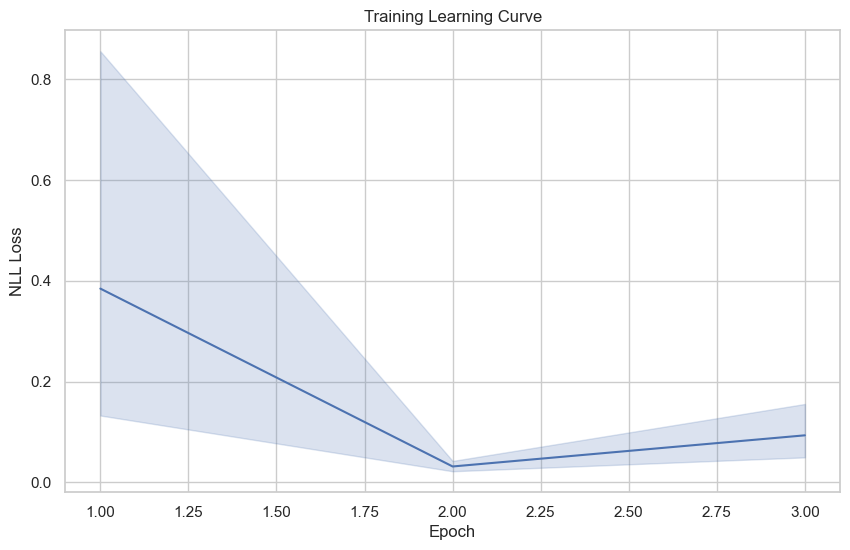

In [33]:
df_learning = parse_training_logs("../results/logs/experiment_2025-12-12_12-35-50.log")

plt.figure(figsize=(10, 6))
sns.lineplot(data=df_learning, x="Epoch", y="Loss")
plt.title("Training Learning Curve")
plt.xlabel("Epoch")
plt.ylabel("NLL Loss")
plt.show()

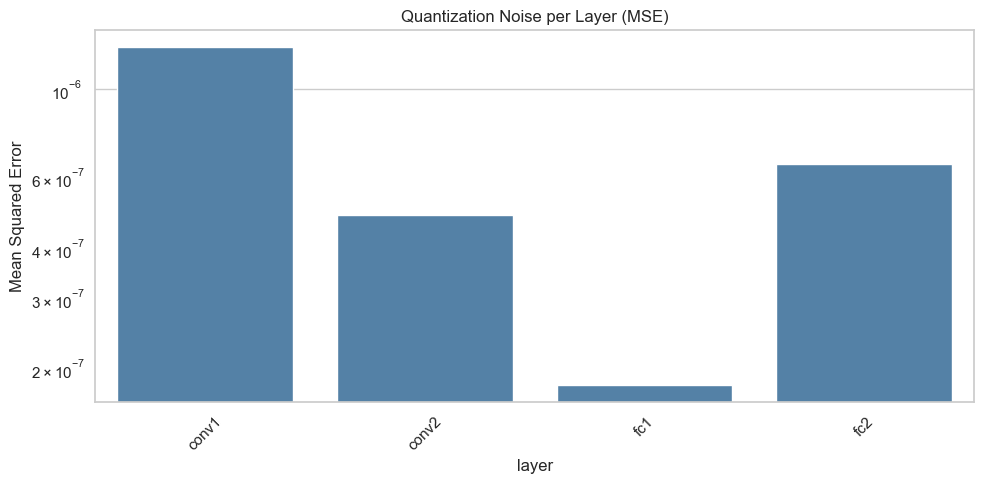

In [34]:
df_loss = pd.read_csv("../results/csv/weight_mse_2025-12-12_12-35-50.csv")

plot = plot_layer_mse(df_loss)


In [35]:
q_model = CNN()
q_model = replace_layers_with_quantizable(q_model)

for name, module in q_model.named_modules():
    if hasattr(module, 'quantized_storage'):
        module.quantized_storage(num_bits=8, method='symmetry')

q_model.load_state_dict(torch.load("../results/quantized_models/cnn_mnist_quantized2025-12-12_16-05-19.pt"))

q_model.eval()

CNN(
  (conv1): QuantizedConv2d(1, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv2): QuantizedConv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): QuantizedLinear(in_features=9216, out_features=128, bias=True)
  (fc2): QuantizedLinear(in_features=128, out_features=10, bias=True)
)

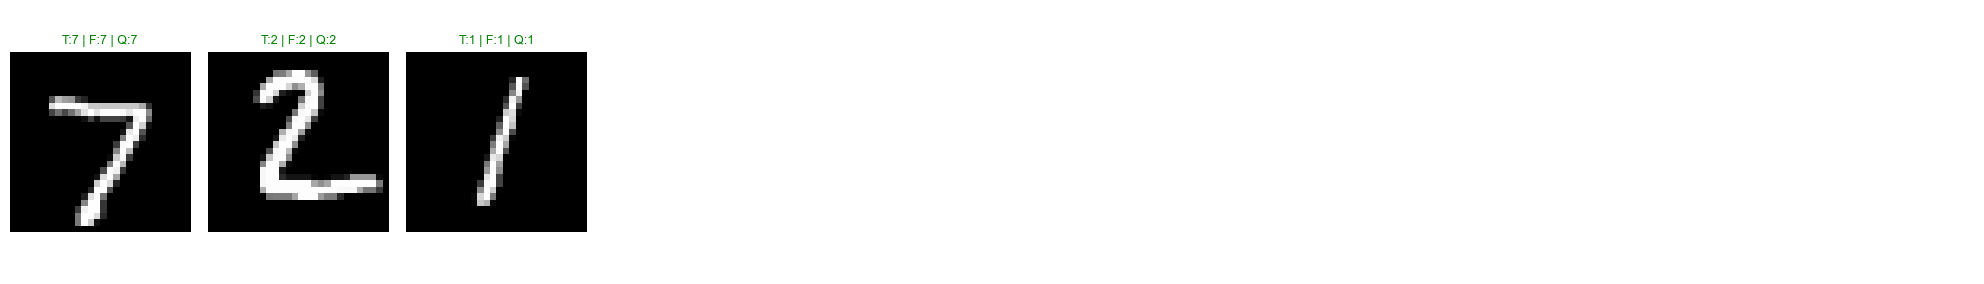

In [40]:
q_model_path = "../results/quantized_models/cnn_mnist_quantized2025-12-12_16-05-19.pt"
f_model_path = "../results/models/cnn_mnist_2025-12-12_16-05-19.pt"

f_model, q_model = load_models(float_path=f_model_path, quant_path=q_model_path)
train_loader, test_loader = get_data_loaders()

visualize_comparison(model_f=f_model, model_q=q_model, test_loader=test_loader, num_images=3)

In [45]:
weights_floats = f_model.conv1.weight.data.clone().cpu()

# Quantisiert (Simuliert: Float -> Int8 -> Float)
# Wir nutzen deine existierende Funktion, um zu sehen, was aus den Floats wird
weights_dequant, _, _, _ = Quantization.quantize_tensor(weights_floats, num_bits=8, method='affine')

# Flatten für Plots
flat_float = weights_floats.view(-1).numpy()
flat_dequant = weights_dequant.view(-1).numpy()

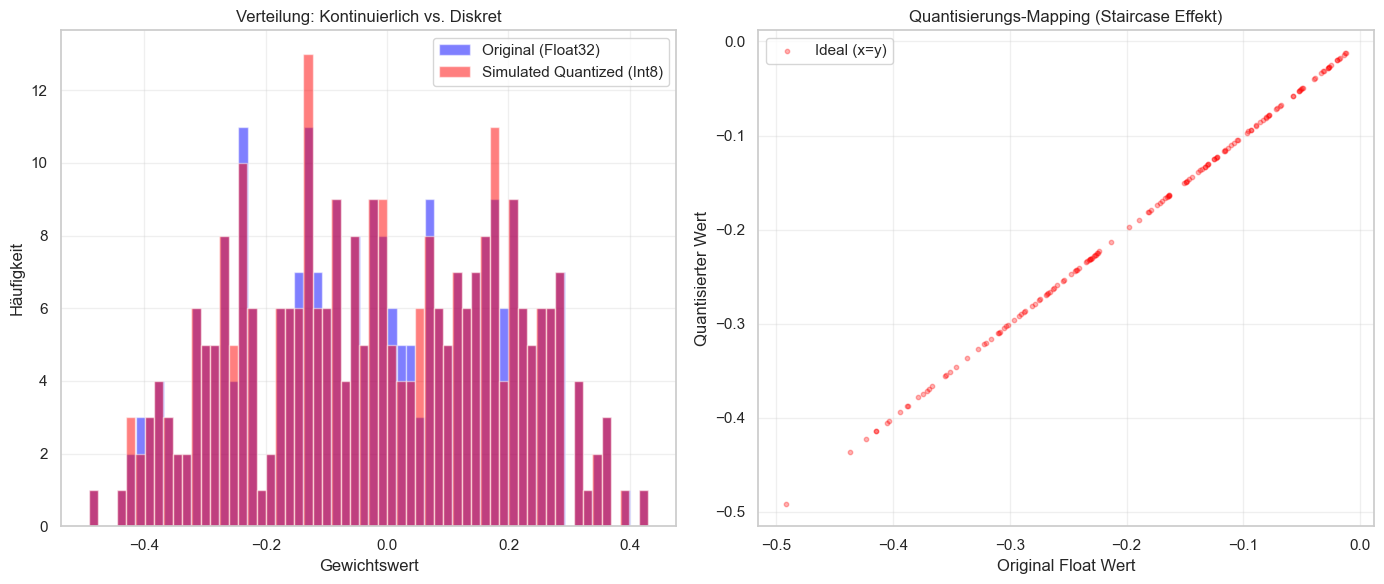

In [ ]:
# -------------------------------------------------------
# PLOT 1: Histogramm Überlagerung
# -------------------------------------------------------
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
# Original
plt.hist(flat_float, bins=60, color='blue', alpha=0.5, label="Original (Float32)")
# Quantized (Zeigt die "Bins")
plt.hist(flat_dequant, bins=60, color='red', alpha=0.5, label="Simulated Quantized (Int8)")

plt.title("Verteilung: Kontinuierlich vs. Diskret")
plt.xlabel("Gewichtswert")
plt.ylabel("Häufigkeit")
plt.legend()
plt.grid(True, alpha=0.3)

# -------------------------------------------------------
# PLOT 2: Die Treppenfunktion (Visualisierung des Fehlers)
# -------------------------------------------------------
plt.subplot(1,2,2)

# Wir nehmen nur eine Teilmenge (z.B. 100 Werte), damit man die Punkte sieht
subset_idx = np.argsort(flat_float)[:150] # Sortieren für schönere Linie

plt.scatter(flat_float[subset_idx], flat_float[subset_idx], 
            color='red', alpha=0.3, label="Ideal (x=y)", s=10)
            
plt.scatter(flat_float[subset_idx], flat_dequant[subset_idx], 
            color='green', alpha=0.9, label="Quantized Mapping", s=15)

plt.title("Quantisierungs-Mapping (Staircase Effekt)")
plt.xlabel("Original Float Wert")
plt.ylabel("Quantisierter Wert")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()